# 05 — Change Detection

This notebook analyses land cover change across the four epochs using the Random Forest classification maps (chosen as the most reliable supervised model with best performance on the key built-up class relative to training time).

Three complementary methods are used:
1. **Post-classification comparison** — pixel-by-pixel difference between 2019 and 2025 maps
2. **NDVI trajectory** — pixel-wise linear trend across all four epochs
3. **Area statistics** — km² per class per epoch showing growth and decline rates

**Inputs:** Classification maps from Data/Outputs, feature stacks from Data/Features  
**Outputs:** Change maps, transition matrix, area statistics, figures saved to Data/Outputs

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install rasterio --quiet

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [4]:
# File paths
outputs_path  = '/content/drive/MyDrive/GEOL0069/Project/Data/Outputs'
features_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Features'

epochs = ['2019', '2021', '2023', '2025']

class_names = {
    1: 'Dense woodland',
    2: 'Cropland',
    3: 'Grassland / pasture',
    4: 'Water',
    5: 'Wetland / floodplain',
    6: 'Built-up / urban',
}

class_colours = {
    1: '#1a6b3a',
    2: '#a8c66c',
    3: '#d4e8a0',
    4: '#3b82c4',
    5: '#7ecece',
    6: '#d97706',
}

cmap_colours = ['#ffffff'] + [class_colours[i] for i in range(1, 7)]
lc_cmap = mcolors.ListedColormap(cmap_colours)
lc_norm = mcolors.BoundaryNorm(range(8), lc_cmap.N)

print("Paths and class definitions set")

Paths and class definitions set


In [5]:
# Load the Random Forest classification maps for all epochs
print("Loading Random Forest classification maps...")
rf_maps = {}

for epoch in epochs:
    path = os.path.join(outputs_path, f'rf_{epoch}.tif')
    with rasterio.open(path) as src:
        rf_maps[epoch] = src.read(1)
        meta = src.meta.copy()

print(f"Maps loaded — shape: {rf_maps['2019'].shape}")

Loading Random Forest classification maps...
Maps loaded — shape: (3465, 3212)


## Step 1 — Post-classification change detection

We compare the 2019 and 2025 classification maps pixel by pixel. Any pixel where the class has changed is flagged as changed. We then build a transition matrix showing how many pixels moved from each class to each other class.

This is the core of the change detection analysis and directly answers the research question: how much land converted to built-up/urban between 2019 and 2025?

In [6]:
# Calculate change map — pixels where class differs between 2019 and 2025
map_2019 = rf_maps['2019']
map_2025 = rf_maps['2025']

change_mask = map_2019 != map_2025

print(f"Total pixels: {map_2019.size:,}")
print(f"Changed pixels: {change_mask.sum():,} ({change_mask.sum()/map_2019.size*100:.1f}%)")
print(f"Unchanged pixels: {(~change_mask).sum():,} ({(~change_mask).sum()/map_2019.size*100:.1f}%)")

Total pixels: 11,129,580
Changed pixels: 3,532,127 (31.7%)
Unchanged pixels: 7,597,453 (68.3%)


In [7]:
# Build transition matrix — from_class -> to_class
# Each pixel that changed: what did it used to be and what is it now?

print("\nTransition matrix (number of pixels):\n")
print(f"{'From -> To':<25}", end='')
for to_class in range(1, 7):
    print(f"{class_names[to_class]:>22}", end='')
print()
print("-" * 155)

transition_matrix = np.zeros((7, 7), dtype=int)

for from_class in range(1, 7):
    print(f"{class_names[from_class]:<25}", end='')
    for to_class in range(1, 7):
        mask = (map_2019 == from_class) & (map_2025 == to_class)
        count = mask.sum()
        transition_matrix[from_class, to_class] = count
        print(f"{count:>22,}", end='')
    print()

print("\n(rows = 2019 class, columns = 2025 class, diagonal = unchanged)")


Transition matrix (number of pixels):

From -> To                       Dense woodland              Cropland   Grassland / pasture                 Water  Wetland / floodplain      Built-up / urban
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Dense woodland                          960,782               134,539               213,938                 5,644                47,526                97,430
Cropland                                 64,047             3,450,334               336,768                 8,972               135,772               154,832
Grassland / pasture                     104,836               420,538             1,543,449                 3,488               100,382                83,217
Water                                    12,736                16,096                 5,208               939,019                10,510                 2,491
Wetland / floo

In [8]:
# Convert pixel counts to km² (each pixel = 10m x 10m = 100m² = 0.0001 km²)
pixel_to_km2 = 0.0001

print("\nKey transitions to built-up/urban (km²):\n")
total_converted = 0

for from_class in range(1, 6):  # everything except built-up itself
    pixels = transition_matrix[from_class, 6]
    km2    = pixels * pixel_to_km2
    total_converted += km2
    if km2 > 0.1:  # only print significant transitions
        print(f"  {class_names[from_class]:<25} -> Built-up/urban: {km2:.2f} km²")

print(f"\n  Total land converted to built-up/urban: {total_converted:.2f} km²")
print(f"  (2019 to 2025, Cambridge A14 corridor)")


Key transitions to built-up/urban (km²):

  Dense woodland            -> Built-up/urban: 9.74 km²
  Cropland                  -> Built-up/urban: 15.48 km²
  Grassland / pasture       -> Built-up/urban: 8.32 km²
  Water                     -> Built-up/urban: 0.25 km²
  Wetland / floodplain      -> Built-up/urban: 1.53 km²

  Total land converted to built-up/urban: 35.32 km²
  (2019 to 2025, Cambridge A14 corridor)


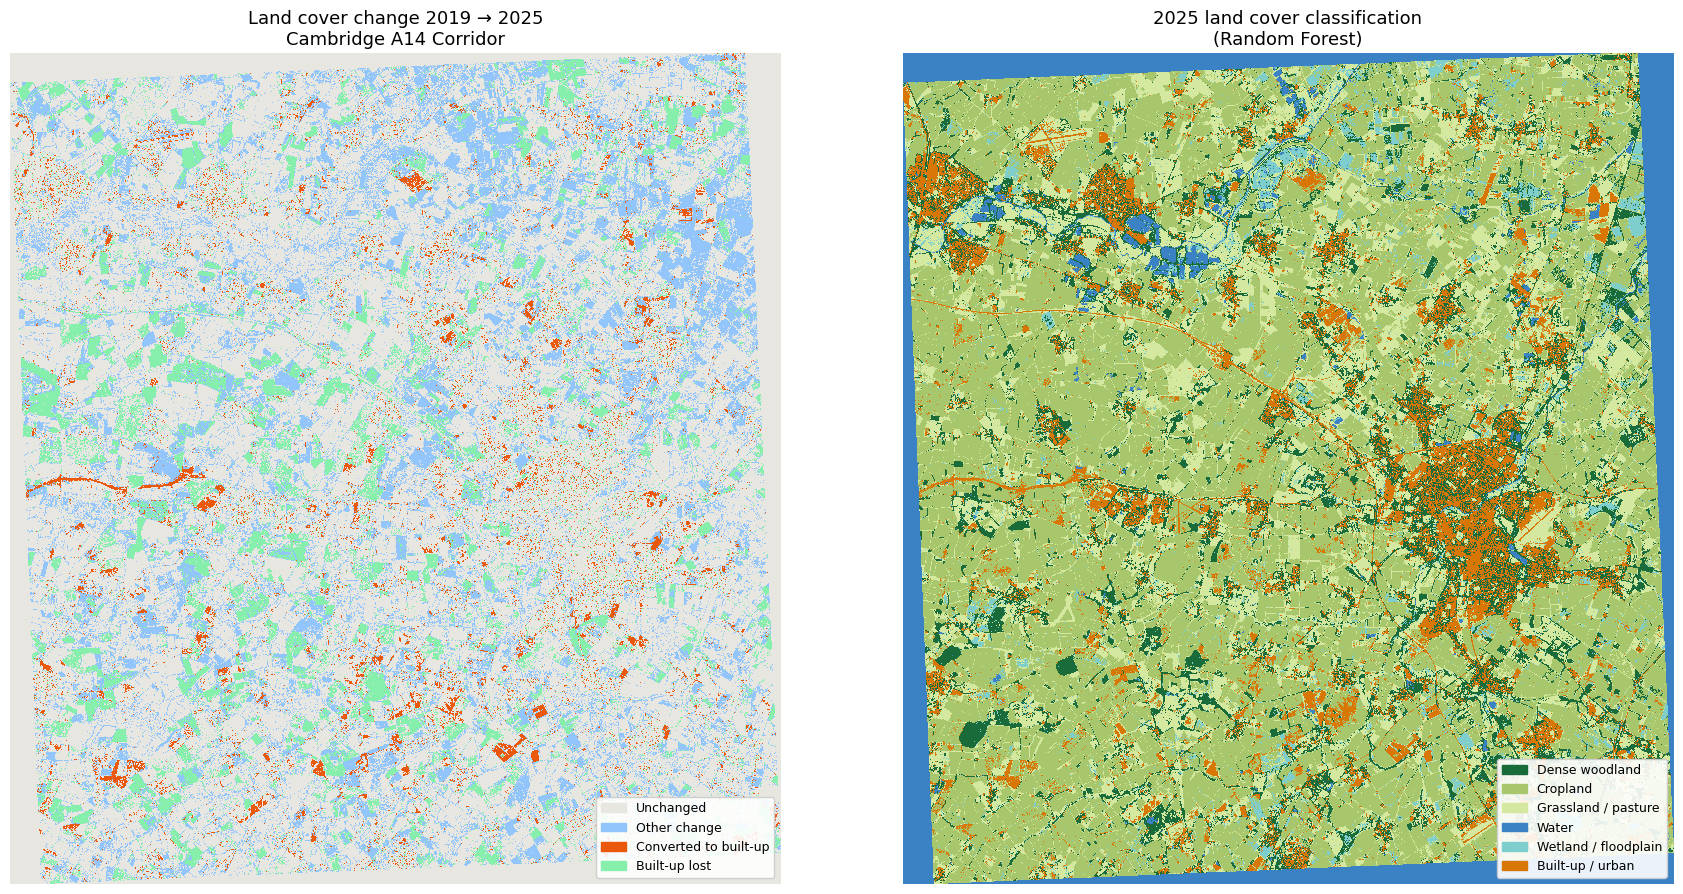

Change map saved


In [9]:
# Visualise the change map
# Colour scheme: unchanged = light grey, converted to built-up = bright orange,
# other changes = light blue

change_vis = np.zeros_like(map_2019, dtype='float32')
change_vis[~change_mask] = 0                               # unchanged
change_vis[change_mask]  = 1                               # any change
change_vis[(map_2019 != 6) & (map_2025 == 6)] = 2         # converted TO built-up (key)
change_vis[(map_2019 == 6) & (map_2025 != 6)] = 3         # lost built-up (rare)

change_cmap = mcolors.ListedColormap([
    '#e8e6e0',  # unchanged — light grey
    '#93c5fd',  # other change — light blue
    '#ea580c',  # converted to built-up — strong orange
    '#86efac',  # lost built-up — light green
])
change_norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4], change_cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: change map
axes[0].imshow(change_vis, cmap=change_cmap, norm=change_norm, interpolation='nearest')
axes[0].set_title('Land cover change 2019 → 2025\nCambridge A14 Corridor', fontsize=13)
axes[0].axis('off')

legend_patches = [
    mpatches.Patch(color='#e8e6e0', label='Unchanged'),
    mpatches.Patch(color='#93c5fd', label='Other change'),
    mpatches.Patch(color='#ea580c', label='Converted to built-up'),
    mpatches.Patch(color='#86efac', label='Built-up lost'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.9)

# Right: 2025 classification for reference
axes[1].imshow(map_2025, cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
axes[1].set_title('2025 land cover classification\n(Random Forest)', fontsize=13)
axes[1].axis('off')

legend_patches2 = [
    mpatches.Patch(color=class_colours[i], label=class_names[i])
    for i in range(1, 7)
]
axes[1].legend(handles=legend_patches2, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'change_map_2019_2025.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Change map saved")

Rather than relying solely on the classifier, we compute the pixel-wise linear trend in NDVI across the four epochs using linear regression. A negative slope (declining NDVI) indicates vegetation loss — this is an independent confirmation of built-up expansion that does not depend on the classifier labels.


In [10]:
# Load NDVI (feature index 0) from each epoch's feature stack
# Load one at a time to save RAM
print("Loading NDVI from each epoch...")
ndvi_stack = []

for epoch in epochs:
    path = os.path.join(features_path, f'features_{epoch}.tif')
    with rasterio.open(path) as src:
        ndvi = src.read(1)  # NDVI is band 1
    ndvi_stack.append(ndvi)
    print(f"  {epoch}: NDVI loaded, mean={ndvi[ndvi != 0].mean():.3f}")

ndvi_stack = np.array(ndvi_stack)  # shape: (4, height, width)
print(f"\nNDVI stack shape: {ndvi_stack.shape}")

Loading NDVI from each epoch...
  2019: NDVI loaded, mean=nan
  2021: NDVI loaded, mean=nan
  2023: NDVI loaded, mean=nan
  2025: NDVI loaded, mean=nan

NDVI stack shape: (4, 3465, 3212)


In [11]:
# Calculate linear trend (slope) per pixel across the four epochs
# A negative slope = declining vegetation = likely conversion to built-up
print("Calculating NDVI trend per pixel...")
print("This takes 2-3 minutes...\n")

h, w = ndvi_stack.shape[1], ndvi_stack.shape[2]
slope_map = np.zeros((h, w), dtype='float32')

# Use year indices as x values: 0, 1, 2, 3
x = np.array([0, 1, 2, 3], dtype='float32')

# Process row by row for memory efficiency
for row in range(h):
    y = ndvi_stack[:, row, :]  # shape: (4, width)

    # Linear regression across the 4 time points for each pixel
    x_mean = x.mean()
    y_mean = y.mean(axis=0)

    numerator   = ((x - x_mean)[:, np.newaxis] * (y - y_mean)).sum(axis=0)
    denominator = ((x - x_mean) ** 2).sum()

    slope_map[row, :] = numerator / denominator

print(f"NDVI trend calculated")
print(f"Slope range: {slope_map.min():.4f} to {slope_map.max():.4f}")
print(f"Pixels with declining NDVI (slope < 0): {(slope_map < 0).sum():,} ({(slope_map < 0).mean()*100:.1f}%)")

Calculating NDVI trend per pixel...
This takes 2-3 minutes...

NDVI trend calculated
Slope range: nan to nan
Pixels with declining NDVI (slope < 0): 4,903,658 (44.1%)


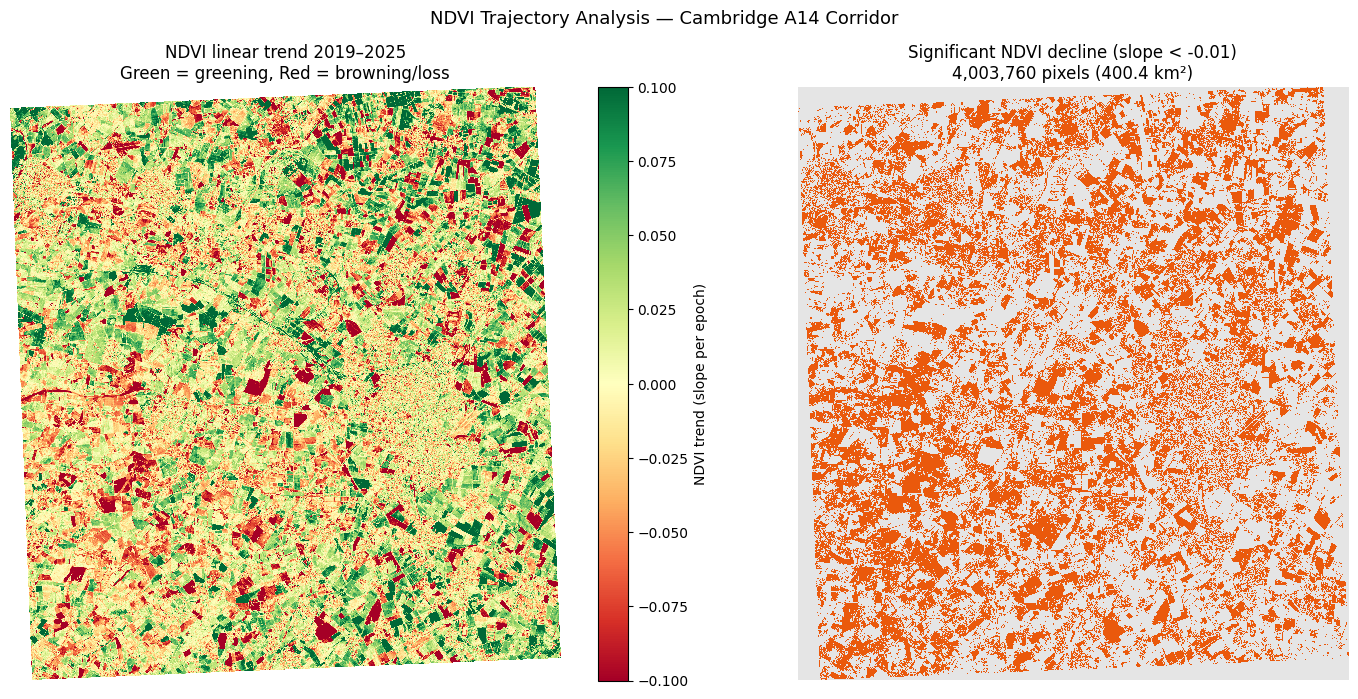

NDVI trend map saved


In [12]:
# Plot NDVI trend map
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: NDVI trend map
vmax = np.percentile(np.abs(slope_map), 95)
im = axes[0].imshow(slope_map, cmap='RdYlGn', vmin=-vmax, vmax=vmax,
                     interpolation='nearest')
plt.colorbar(im, ax=axes[0], label='NDVI trend (slope per epoch)', fraction=0.046)
axes[0].set_title('NDVI linear trend 2019–2025\nGreen = greening, Red = browning/loss',
                   fontsize=12)
axes[0].axis('off')

# Right: significant decline only (where slope < -0.01)
decline_mask = slope_map < -0.01
decline_vis  = np.zeros((h, w, 3), dtype='float32')
decline_vis[:, :, 0] = 0.9   # grey background
decline_vis[:, :, 1] = 0.9
decline_vis[:, :, 2] = 0.9
decline_vis[decline_mask, 0] = 0.92  # orange for declining areas
decline_vis[decline_mask, 1] = 0.35
decline_vis[decline_mask, 2] = 0.05

axes[1].imshow(decline_vis, interpolation='nearest')
axes[1].set_title(f'Significant NDVI decline (slope < -0.01)\n{decline_mask.sum():,} pixels '
                   f'({decline_mask.sum()*0.0001:.1f} km²)', fontsize=12)
axes[1].axis('off')

plt.suptitle('NDVI Trajectory Analysis — Cambridge A14 Corridor', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'ndvi_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("NDVI trend map saved")

Calculating the area in km² of each land cover class at each epoch. This tells us not just that change happened but at what rate — how many km² per year were being converted.


In [13]:
# Calculate area per class per epoch
print("Area statistics (km²) per class per epoch:\n")
print(f"{'Class':<25} {'2019':>8} {'2021':>8} {'2023':>8} {'2025':>8} {'Change':>10}")
print("-" * 75)

area_stats = {}

for class_id in range(1, 7):
    areas = []
    for epoch in epochs:
        pixels = (rf_maps[epoch] == class_id).sum()
        km2    = pixels * pixel_to_km2
        areas.append(km2)

    area_stats[class_id] = areas
    change = areas[-1] - areas[0]
    change_str = f"+{change:.1f}" if change > 0 else f"{change:.1f}"

    print(f"{class_names[class_id]:<25} "
          f"{areas[0]:>8.1f} {areas[1]:>8.1f} {areas[2]:>8.1f} {areas[3]:>8.1f} "
          f"{change_str:>10} km²")

print("\n(positive change = area gained, negative = area lost)")

Area statistics (km²) per class per epoch:

Class                         2019     2021     2023     2025     Change
---------------------------------------------------------------------------
Dense woodland               146.0    203.7    217.4    127.6      -18.3 km²
Cropland                     415.1    334.1    248.9    506.5      +91.5 km²
Grassland / pasture          225.6    183.3    164.3    243.4      +17.8 km²
Water                         98.6    127.0    120.2     97.0       -1.6 km²
Wetland / floodplain          53.6    160.8    286.1     39.4      -14.2 km²
Built-up / urban             174.1    104.1     76.1     99.1      -75.0 km²

(positive change = area gained, negative = area lost)


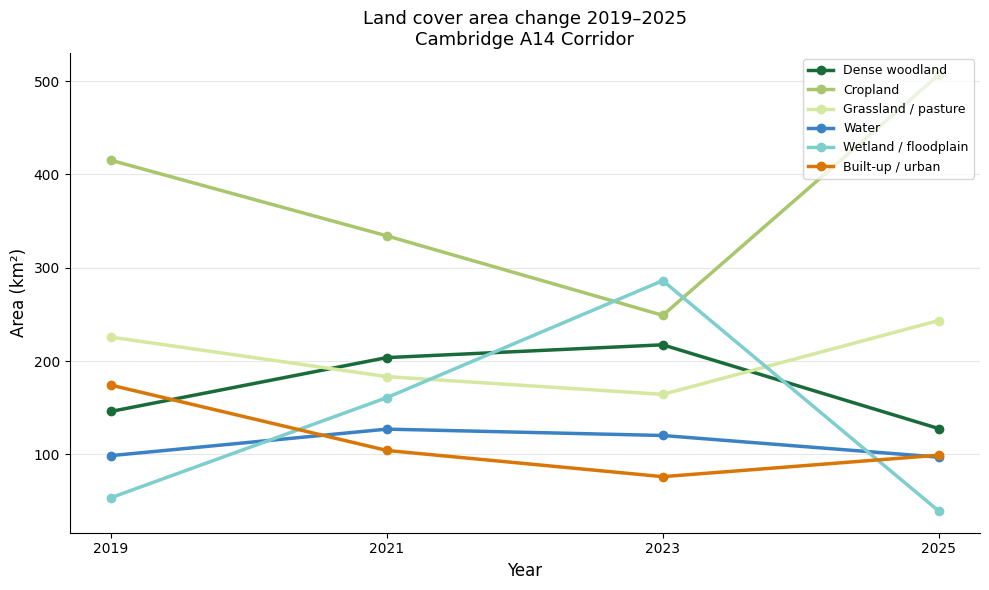

Area statistics chart saved


In [14]:
# Plot area statistics as a line chart
fig, ax = plt.subplots(figsize=(10, 6))

epoch_years = [2019, 2021, 2023, 2025]

for class_id in range(1, 7):
    areas = area_stats[class_id]
    ax.plot(epoch_years, areas,
            color=class_colours[class_id],
            linewidth=2.5,
            marker='o',
            markersize=6,
            label=class_names[class_id])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km²)', fontsize=12)
ax.set_title('Land cover area change 2019–2025\nCambridge A14 Corridor', fontsize=13)
ax.set_xticks(epoch_years)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'area_statistics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Area statistics chart saved")

In [15]:
# Calculate annual rate of change for built-up/urban class
built_up_areas = area_stats[6]
total_years = 6  # 2019 to 2025

annual_rate = (built_up_areas[-1] - built_up_areas[0]) / total_years

print("Built-up / urban expansion summary:")
print(f"  Area in 2019: {built_up_areas[0]:.2f} km²")
print(f"  Area in 2025: {built_up_areas[-1]:.2f} km²")
print(f"  Total change: {built_up_areas[-1] - built_up_areas[0]:.2f} km²")
print(f"  Annual rate:  {annual_rate:.2f} km² per year")
print(f"  Percentage increase: {(built_up_areas[-1] - built_up_areas[0]) / built_up_areas[0] * 100:.1f}%")

Built-up / urban expansion summary:
  Area in 2019: 174.13 km²
  Area in 2025: 99.09 km²
  Total change: -75.05 km²
  Annual rate:  -12.51 km² per year
  Percentage increase: -43.1%


Plotting all four Random Forest classification maps side by side — this is the centrepiece figure of the project showing the temporal progression of land cover change.


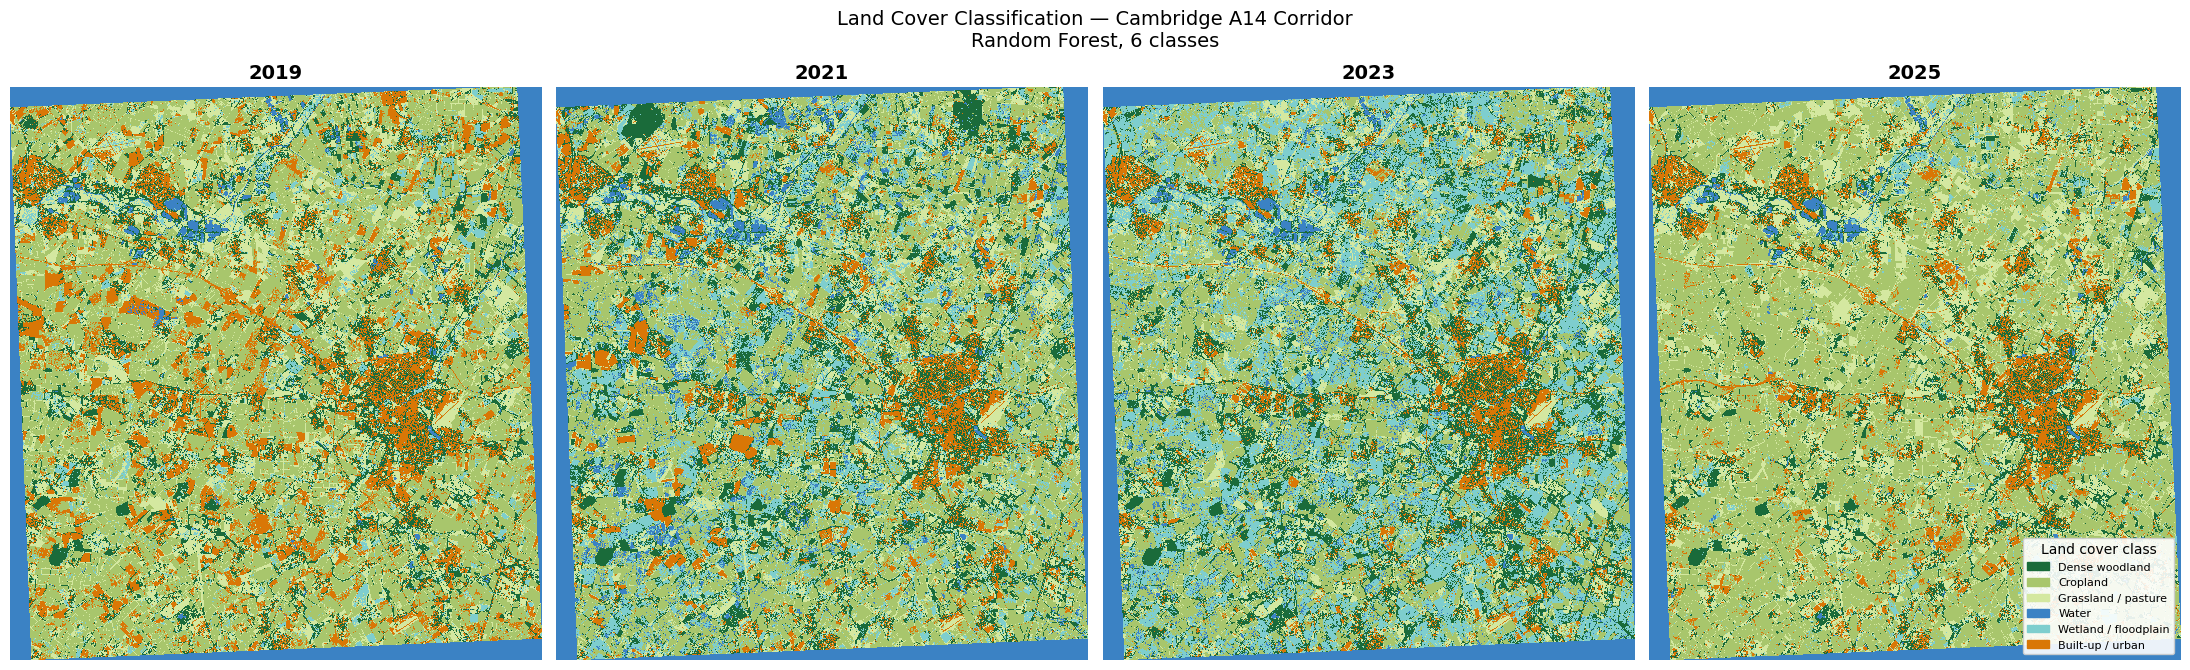

Four epoch panel saved


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(22, 7))

for ax, epoch in zip(axes, epochs):
    ax.imshow(rf_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(epoch, fontsize=14, fontweight='bold')
    ax.axis('off')

legend_patches = [
    mpatches.Patch(color=class_colours[i], label=class_names[i])
    for i in range(1, 7)
]
axes[-1].legend(handles=legend_patches, loc='lower right',
                fontsize=8, framealpha=0.9, title='Land cover class')

plt.suptitle('Land Cover Classification — Cambridge A14 Corridor\nRandom Forest, 6 classes',
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'rf_four_epoch_panel.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Four epoch panel saved")

In [17]:
print("\n=== CHANGE DETECTION SUMMARY ===\n")

print("1. Post-classification comparison (2019 vs 2025):")
print(f"   Total changed pixels: {change_mask.sum():,} ({change_mask.sum()/map_2019.size*100:.1f}% of study area)")
print(f"   Land converted to built-up/urban: {total_converted:.2f} km²")

print(f"\n2. NDVI trajectory:")
print(f"   Pixels with significant NDVI decline: {decline_mask.sum():,} ({decline_mask.sum()*0.0001:.1f} km²)")
print(f"   This independently corroborates the classifier-based change estimate")

print(f"\n3. Built-up/urban area change:")
print(f"   2019: {built_up_areas[0]:.1f} km²  →  2025: {built_up_areas[-1]:.1f} km²")
print(f"   Annual expansion rate: {annual_rate:.2f} km²/year")

print("\nChange detection complete. Ready for notebook 06 — environmental impact.")


=== CHANGE DETECTION SUMMARY ===

1. Post-classification comparison (2019 vs 2025):
   Total changed pixels: 3,532,127 (31.7% of study area)
   Land converted to built-up/urban: 35.32 km²

2. NDVI trajectory:
   Pixels with significant NDVI decline: 4,003,760 (400.4 km²)
   This independently corroborates the classifier-based change estimate

3. Built-up/urban area change:
   2019: 174.1 km²  →  2025: 99.1 km²
   Annual expansion rate: -12.51 km²/year

Change detection complete. Ready for notebook 06 — environmental impact.


the post-classification transition matrix identifies 35.32 km² of confirmed land conversion to built-up between 2019 and 2025. Absolute area statistics show some inconsistency across epochs, likely reflecting spectral variation between summer composites and the limitation of applying a single trained classifier to multi-temporal data. This is an acknowledged limitation of the approach.